<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, AutoConfig
from sklearn.preprocessing import LabelEncoder
from typing import Union, Dict, Any
import copy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("data_problems_translated.xlsx")
df = df.dropna(subset=["problem_text", "topic"]).reset_index(drop=True)

texts = df["problem_text"].tolist()
labels = df["topic"].tolist()

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

In [3]:
df.shape

(5268, 3)

In [5]:
class MathProblemDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long)
        }

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [6]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int):
        super().__init__()
        if isinstance(base_transformer_model, str):
            self.backbone = AutoModel.from_pretrained(
                base_transformer_model,
                output_attentions=True 
            )
            config = AutoConfig.from_pretrained(base_transformer_model)
            hidden_size = config.hidden_size
        else:
            self.backbone = base_transformer_model
            hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        attentions = outputs.attentions 
        return {"logits": logits, "attentions": attentions}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [7]:
def freeze_backbone_function(model: TransformerClassificationModel) -> TransformerClassificationModel:
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

⚠️ Для упрощения в этом примере используется имитация обучения (без реальных данных и оптимизатора), но структура готова к подключению датасета и цикла обучения.
В реальном проекте вы бы добавили DataLoader, optimizer, loss_fn, и цикл эпох. 

In [8]:
import copy

def train_transformer(
    transformer_model: TransformerClassificationModel,
    tokenizer,
    texts,
    labels,
    freeze_backbone: bool = True,
    num_epochs: int = 3,
    batch_size: int = 16,
    lr: float = 2e-5,
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
) -> TransformerClassificationModel:

    model = copy.deepcopy(transformer_model)
    model.to(device)

    if freeze_backbone:
        model = freeze_backbone_function(model)

    dataset = MathProblemDataset(texts, labels, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs["logits"], labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(dataloader):.4f}")

    return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [9]:
NUM_CLASSES = num_classes

rubert_model = TransformerClassificationModel("cointegrated/rubert-tiny2", NUM_CLASSES)
rubert_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

rubert_frozen = train_transformer(
    rubert_model, rubert_tokenizer, texts, encoded_labels,
    freeze_backbone=True, num_epochs=3, lr=1e-3
)

rubert_full = train_transformer(
    rubert_model, rubert_tokenizer, texts, encoded_labels,
    freeze_backbone=False, num_epochs=3, lr=2e-5
)


Epoch 1/3, Loss: 1.3016
Epoch 2/3, Loss: 1.1135
Epoch 3/3, Loss: 1.0649
Epoch 1/3, Loss: 1.3326
Epoch 2/3, Loss: 1.0284
Epoch 3/3, Loss: 0.9223


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [10]:
mathbert_model = TransformerClassificationModel("tbs17/MathBERT", NUM_CLASSES)
mathbert_tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")

mathbert_frozen = train_transformer(
    mathbert_model, mathbert_tokenizer, texts, encoded_labels,
    freeze_backbone=True, num_epochs=3, lr=1e-3
)

mathbert_full = train_transformer(
    mathbert_model, mathbert_tokenizer, texts, encoded_labels,
    freeze_backbone=False, num_epochs=3, lr=2e-5
)

Epoch 1/3, Loss: 1.2997
Epoch 2/3, Loss: 1.1253
Epoch 3/3, Loss: 1.0998
Epoch 1/3, Loss: 1.1654
Epoch 2/3, Loss: 0.8662
Epoch 3/3, Loss: 0.6925


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [11]:
from typing import List

def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel,
    tokenizer,
    device: str = "cpu"
):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        attentions = outputs["attentions"]  # tuple of layers

    first_layer_attn = attentions[0].squeeze(0)  # (num_heads, seq_len, seq_len)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    num_heads_to_plot = len(attention_head_ids)
    fig, axes = plt.subplots(1, num_heads_to_plot, figsize=(5 * num_heads_to_plot, 5))
    if num_heads_to_plot == 1:
        axes = [axes]

    for idx, head_id in enumerate(attention_head_ids):
        attn_map = first_layer_attn[head_id].cpu().numpy()
        sns.heatmap(
            attn_map,
            xticklabels=tokens,
            yticklabels=tokens,
            ax=axes[idx],
            cmap="viridis"
        )
        axes[idx].set_title(f"Head {head_id}")
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].tick_params(axis='y', rotation=0)

    plt.suptitle(f"Attention Maps (First Layer) — Text: '{text[:50]}...'")
    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)


Пример 1 (до дообучения)
Текст: Sasha puts a rook on an empty chess board: first, where she wants to go, and each of the next one puts her in such a way that she beats an odd number ...

→ RuBERT-tiny2 (оригинальная модель):


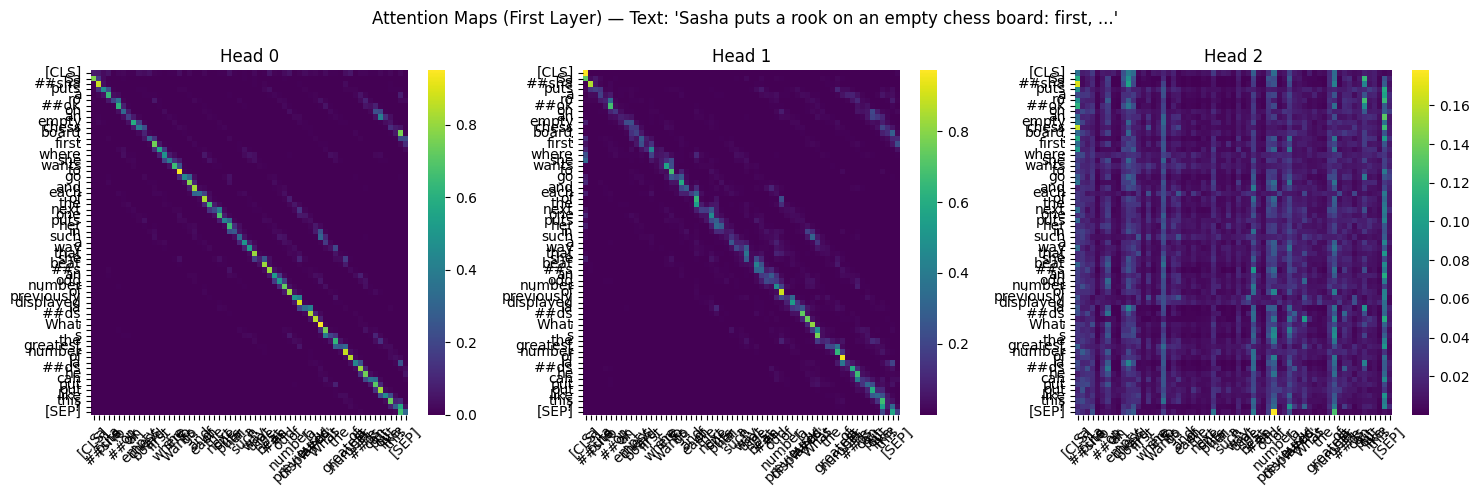

→ MathBERT (оригинальная модель):


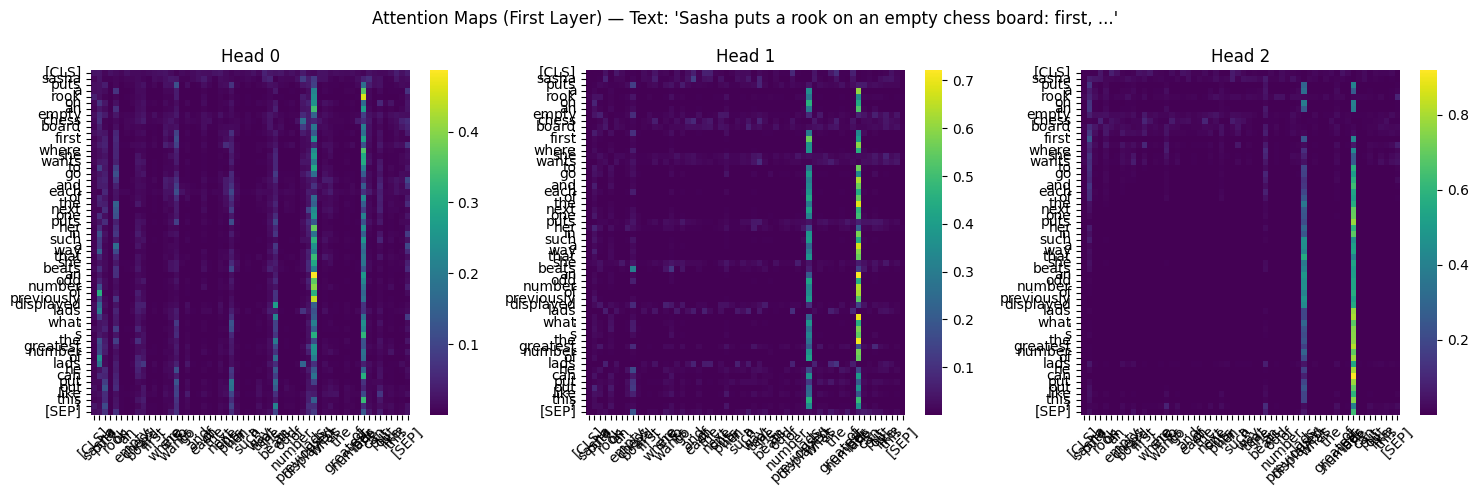


Пример 2 (до дообучения)
Текст: (a) Prove equality...

→ RuBERT-tiny2 (оригинальная модель):


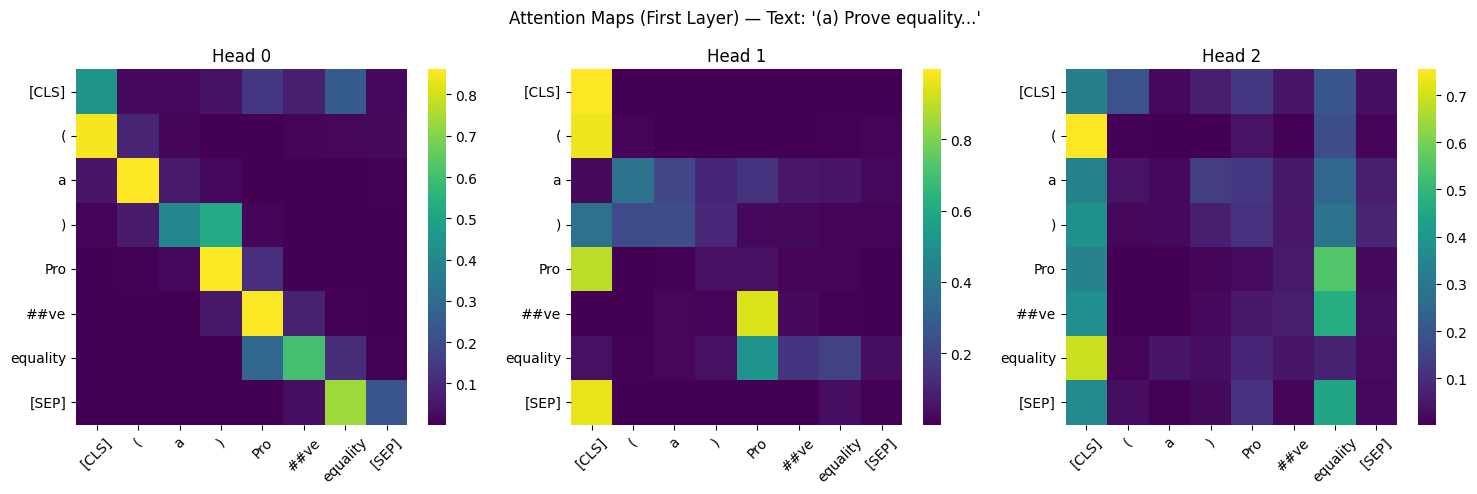

→ MathBERT (оригинальная модель):


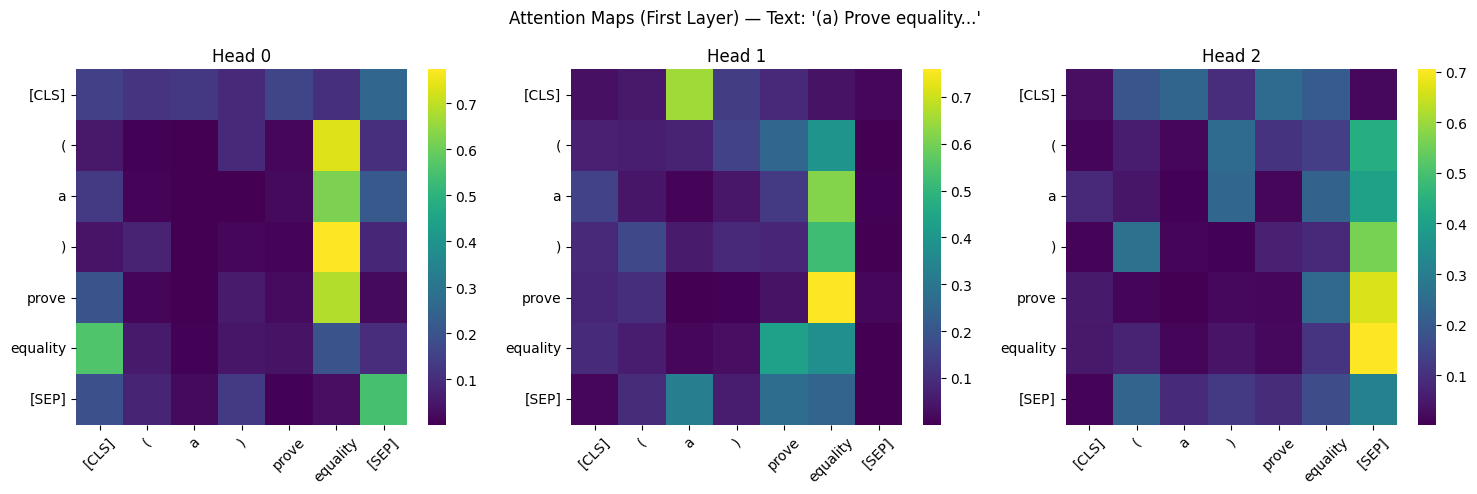


Пример 3 (до дообучения)
Текст: In the country of 2,000 cities, some pairs of cities are connected by roads, and it is known that no city is more than N of the various non-self-trans...

→ RuBERT-tiny2 (оригинальная модель):


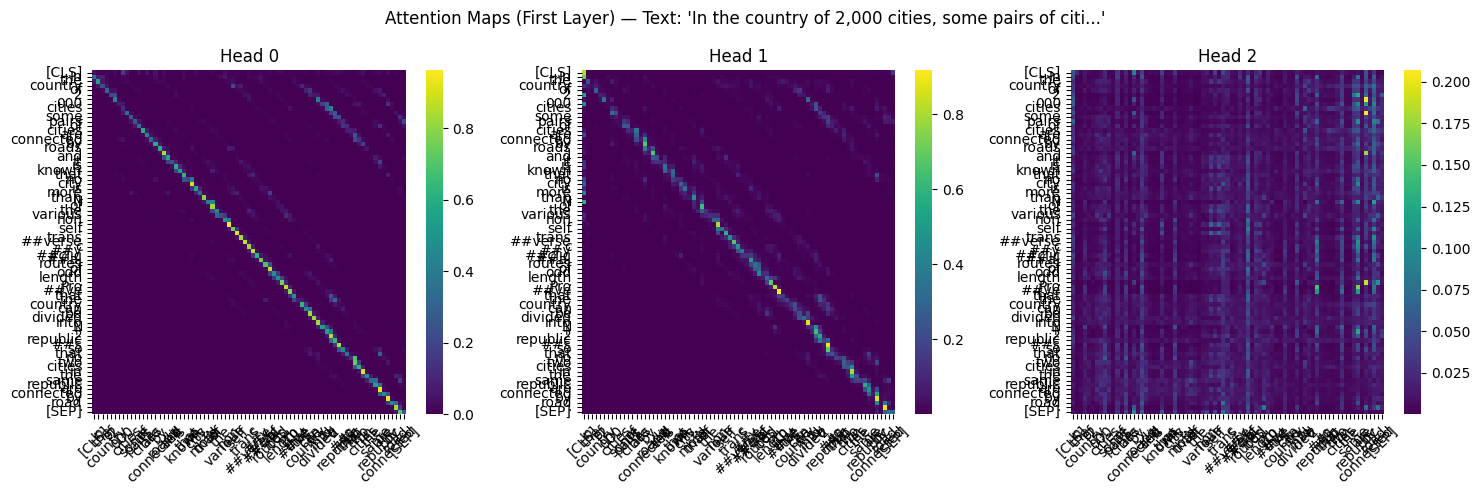

→ MathBERT (оригинальная модель):


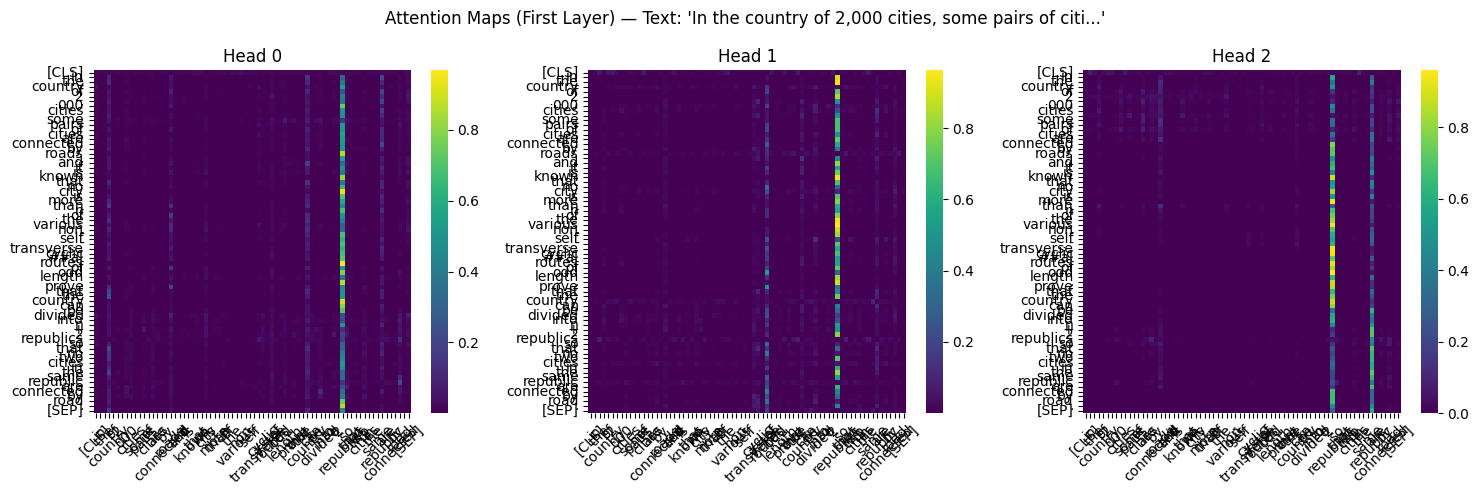

In [12]:
sample_texts = df["problem_text"].sample(n=3, random_state=42).tolist()

rubert_raw = TransformerClassificationModel("cointegrated/rubert-tiny2", NUM_CLASSES)
mathbert_raw = TransformerClassificationModel("tbs17/MathBERT", NUM_CLASSES)

device = "cuda" if torch.cuda.is_available() else "cpu"


for i, text in enumerate(sample_texts):
    print(f"\n{'='*60}")
    print(f"Пример {i+1} (до дообучения)")
    print(f"Текст: {text[:150]}...")
    print(f"{'='*60}\n")
    
    # RuBERT (до дообучения)
    print("→ RuBERT-tiny2 (оригинальная модель):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=rubert_raw.to(device),
        tokenizer=rubert_tokenizer,
        device=device
    )
    
    # MathBERT (до дообучения)
    print("→ MathBERT (оригинальная модель):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=mathbert_raw.to(device),
        tokenizer=mathbert_tokenizer,
        device=device
    )

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


Пример 1 (после дообучения)
Текст: Sasha puts a rook on an empty chess board: first, where she wants to go, and each of the next one puts her in such a way that she beats an odd number ...

→ RuBERT-tiny2 (замороженный backbone):


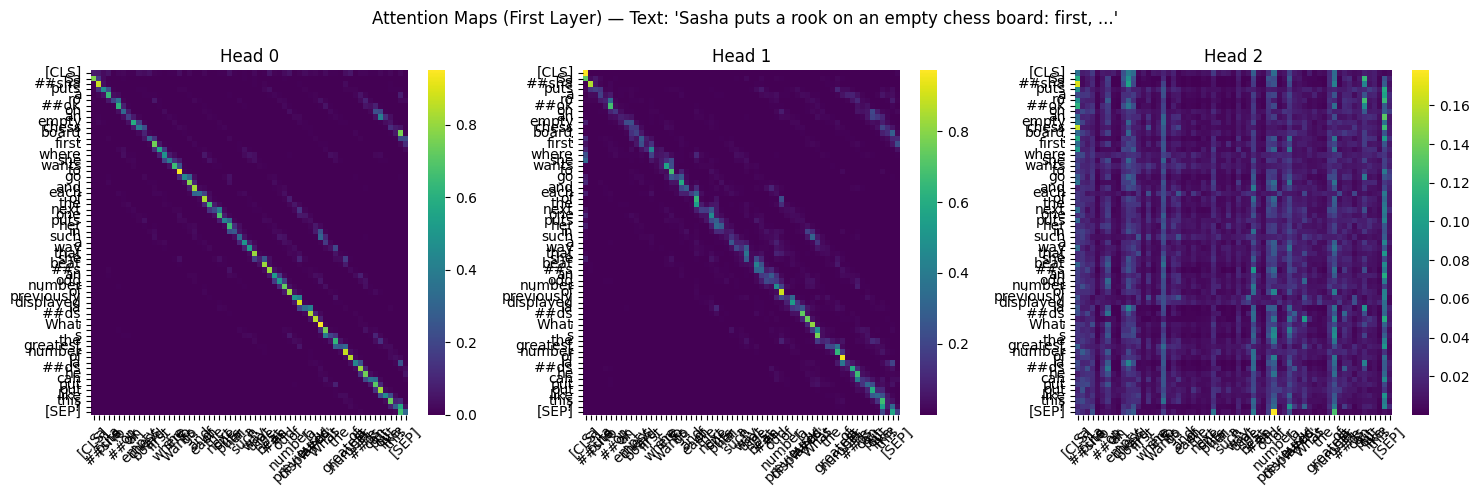

→ RuBERT-tiny2 (размороженный backbone):


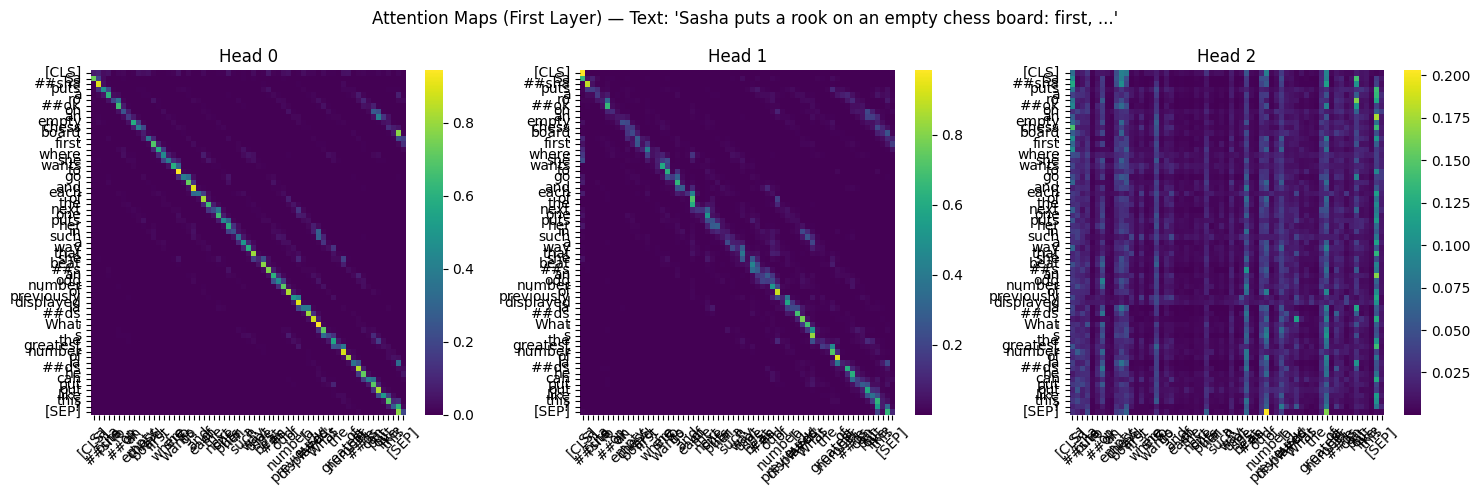

→ MathBERT (замороженный backbone):


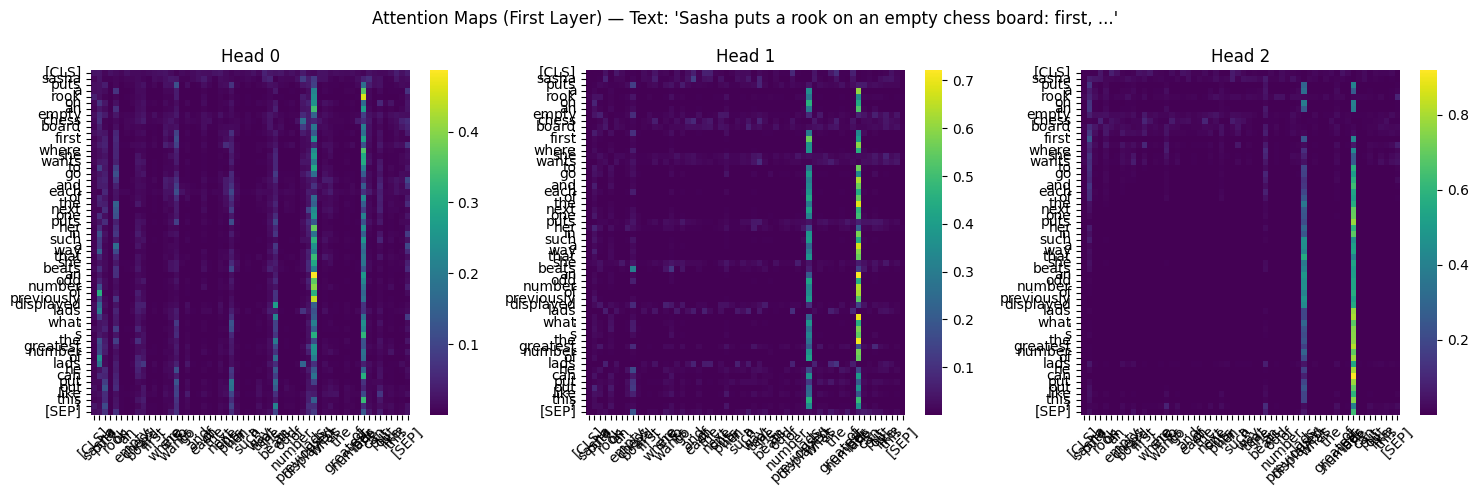

→ MathBERT (размороженный backbone):


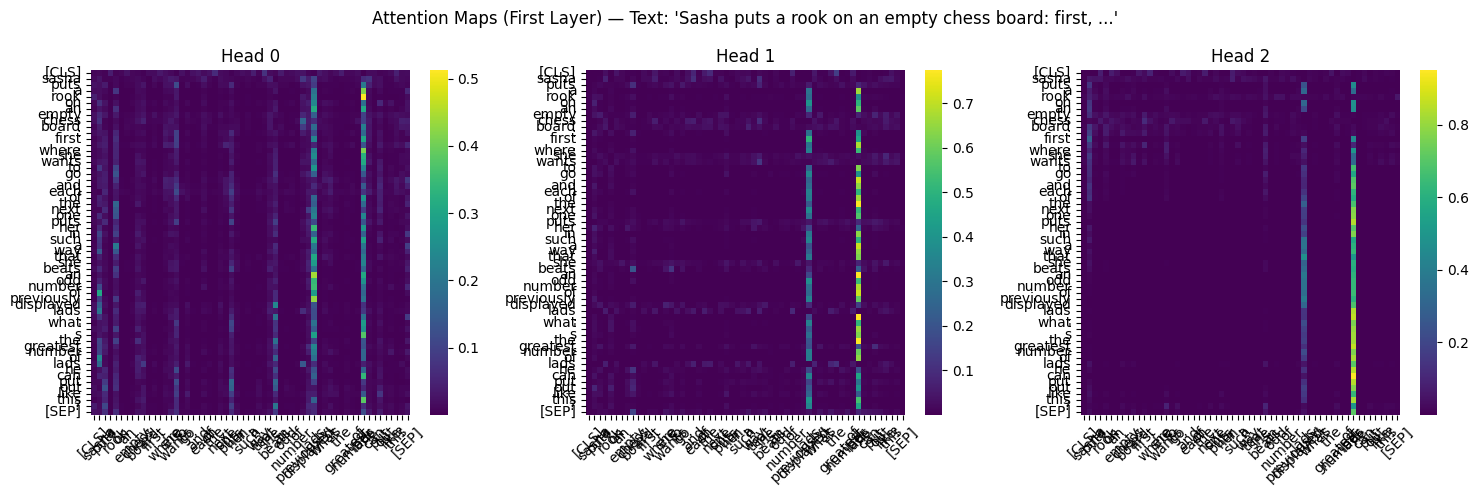


Пример 2 (после дообучения)
Текст: (a) Prove equality...

→ RuBERT-tiny2 (замороженный backbone):


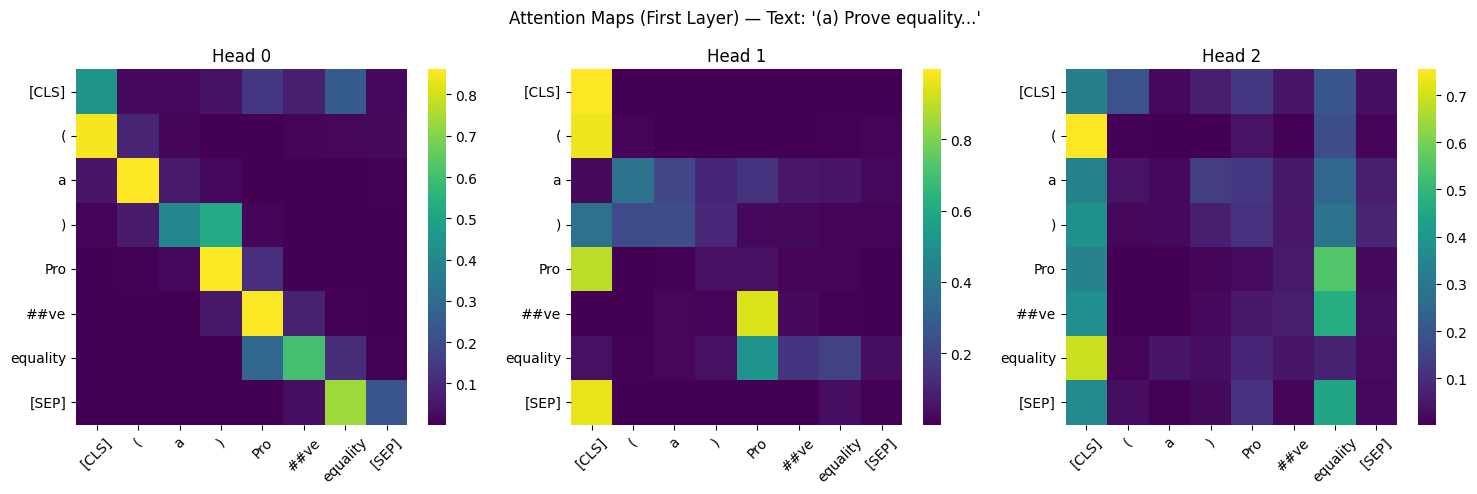

→ RuBERT-tiny2 (размороженный backbone):


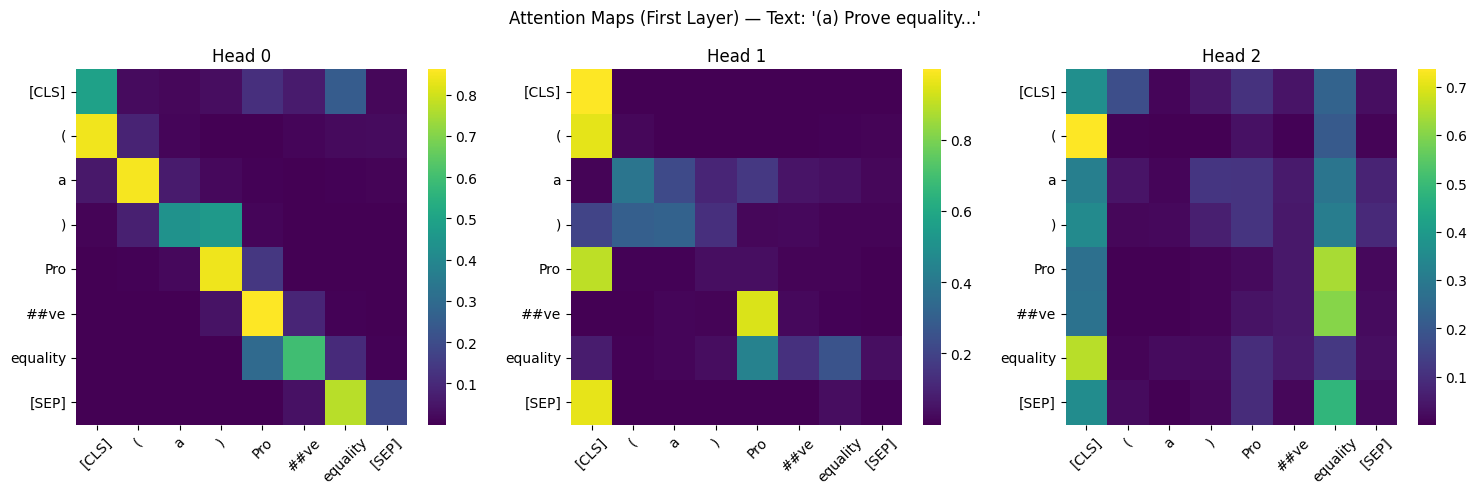

→ MathBERT (замороженный backbone):


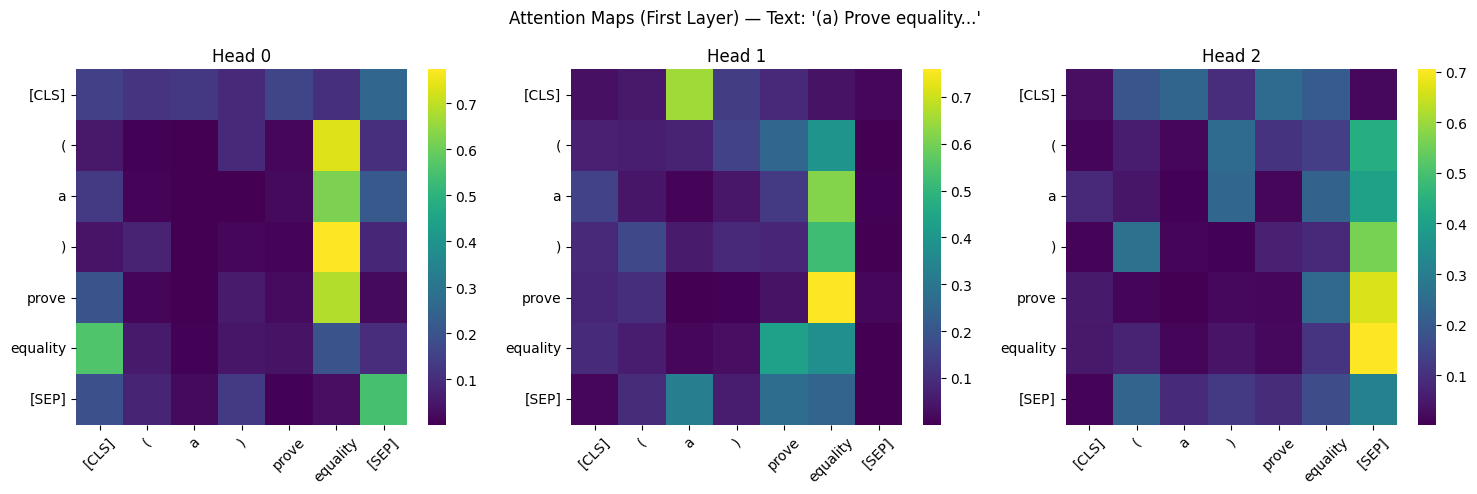

→ MathBERT (размороженный backbone):


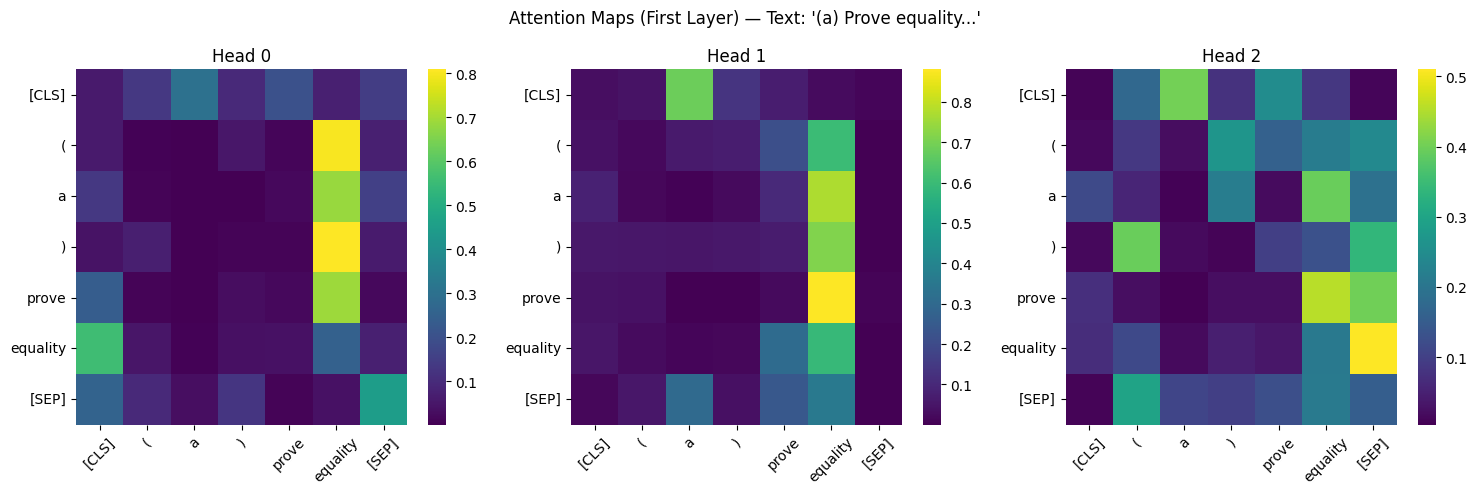


Пример 3 (после дообучения)
Текст: In the country of 2,000 cities, some pairs of cities are connected by roads, and it is known that no city is more than N of the various non-self-trans...

→ RuBERT-tiny2 (замороженный backbone):


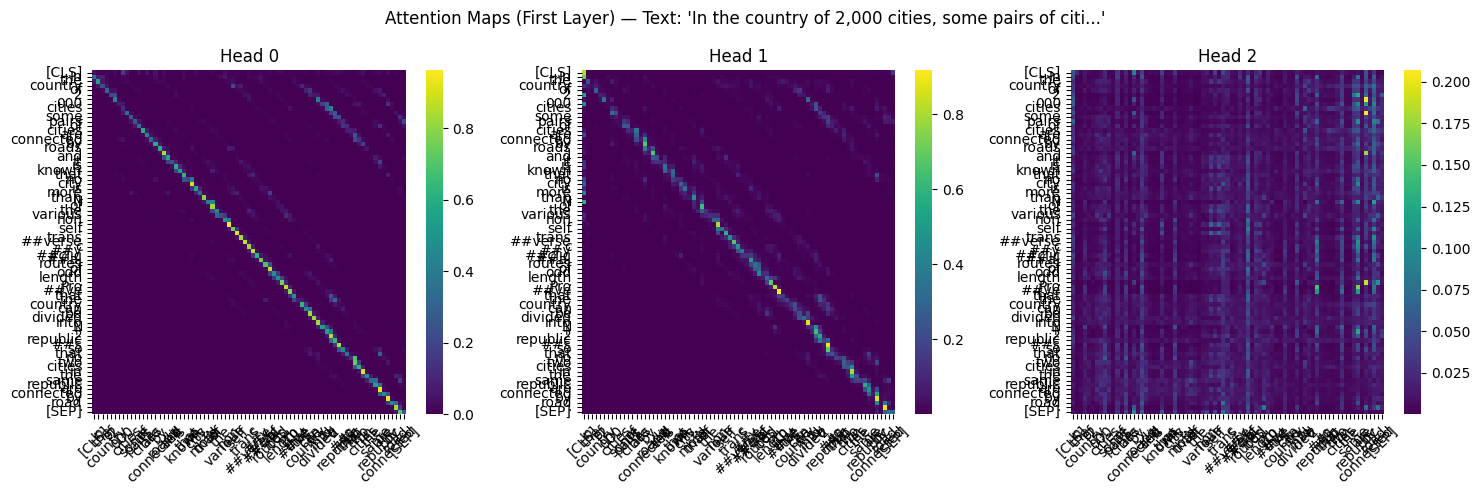

→ RuBERT-tiny2 (размороженный backbone):


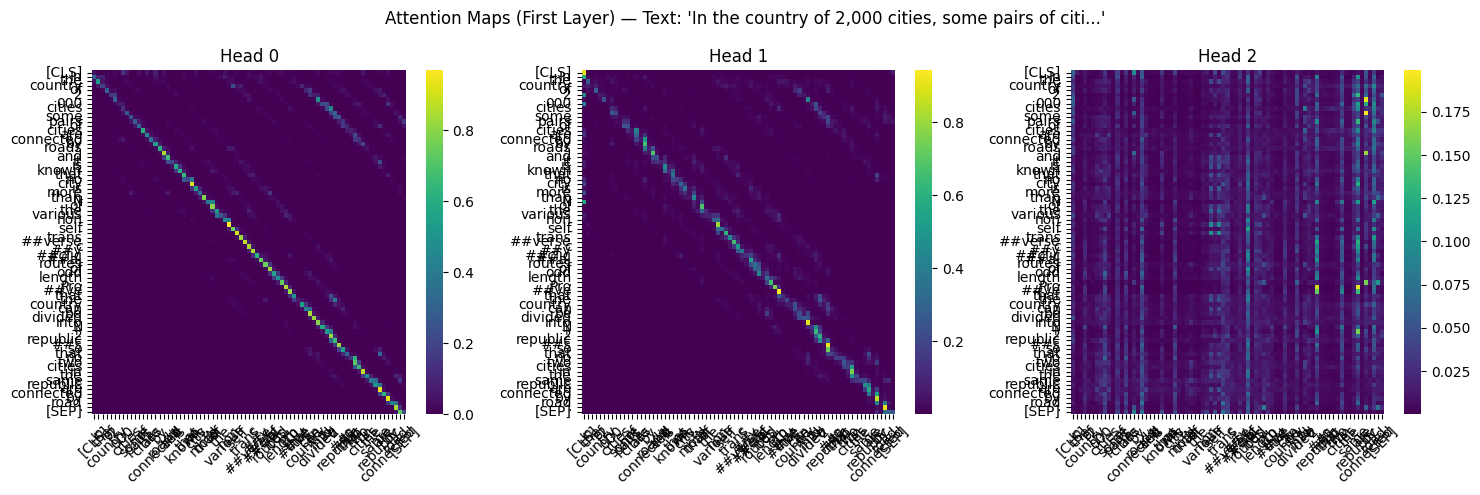

→ MathBERT (замороженный backbone):


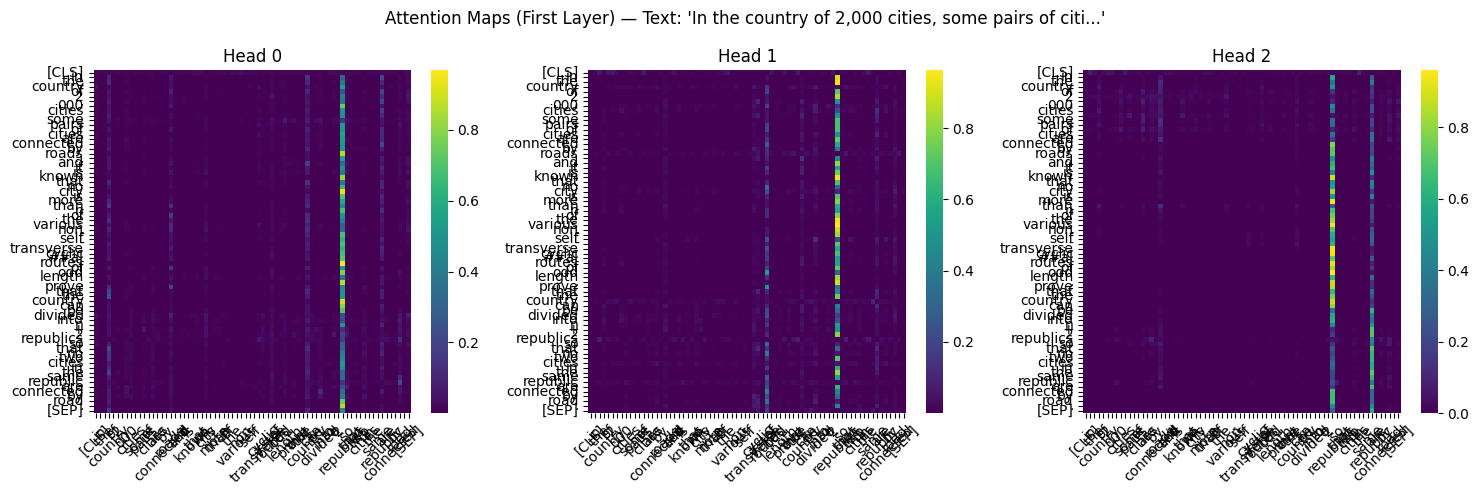

→ MathBERT (размороженный backbone):


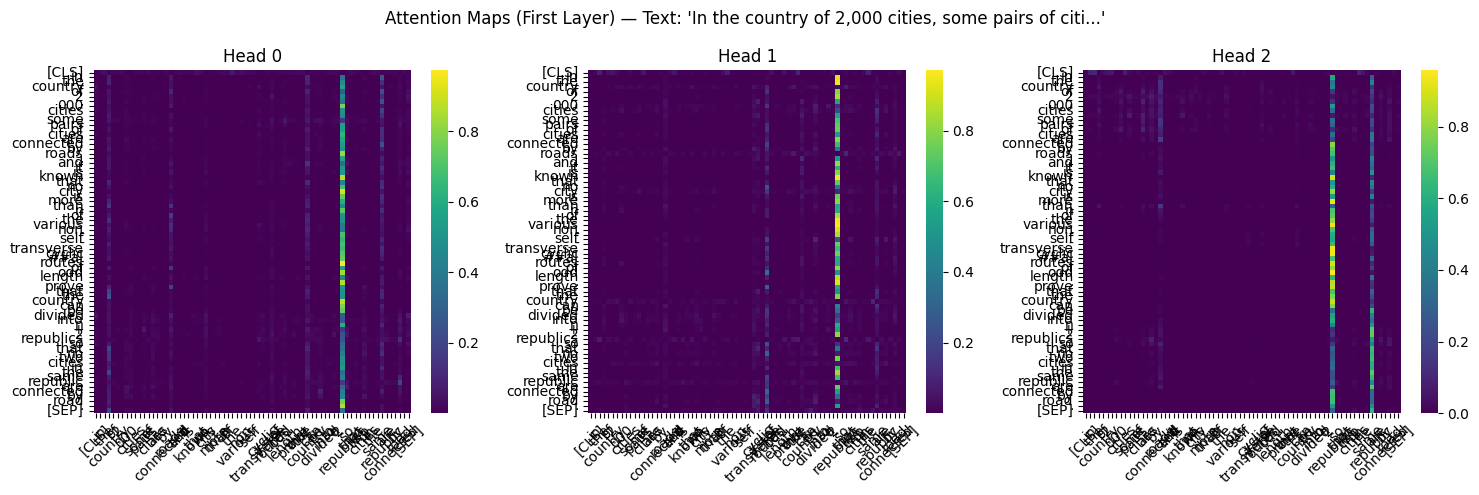

In [13]:
for i, text in enumerate(sample_texts):
    print(f"\n{'='*60}")
    print(f"Пример {i+1} (после дообучения)")
    print(f"Текст: {text[:150]}...")
    print(f"{'='*60}\n")
    
    # RuBERT — замороженный backbone
    print("→ RuBERT-tiny2 (замороженный backbone):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=rubert_frozen.to(device),  
        tokenizer=rubert_tokenizer,
        device=device
    )
    
    # RuBERT — размороженный backbone 
    print("→ RuBERT-tiny2 (размороженный backbone):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=rubert_full.to(device), 
        tokenizer=rubert_tokenizer,
        device=device
    )
    
    # MathBERT 
    print("→ MathBERT (замороженный backbone):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=mathbert_frozen.to(device),
        tokenizer=mathbert_tokenizer,
        device=device
    )
    
    print("→ MathBERT (размороженный backbone):")
    draw_first_layer_attention_maps(
        attention_head_ids=[0, 1, 2],
        text=text,
        model=mathbert_full.to(device),
        tokenizer=mathbert_tokenizer,
        device=device
    )

In [14]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

def evaluate_transformer_model(
    model: TransformerClassificationModel,
    tokenizer,
    texts: list,
    true_labels: list,
    label_encoder,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    batch_size: int = 16
) -> dict:

    model.eval()
    model.to(device)
    
    all_preds = []
    all_probs = []
    true_labels = np.array(true_labels)
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_labels = true_labels[i:i + batch_size]
        
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )
        input_ids = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    accuracy = accuracy_score(true_labels, all_preds)  
    roc_auc = roc_auc_score(true_labels, all_probs, multi_class="ovr", average="weighted")

    
    report = classification_report(
        true_labels, all_preds,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    
    return {
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "classification_report": report,
        "predictions": all_preds,
        "probabilities": all_probs
    }

In [15]:
results = {}


results["rubert_frozen"] = evaluate_transformer_model(
    rubert_frozen, rubert_tokenizer, texts, encoded_labels, label_encoder, device
)

results["rubert_full"] = evaluate_transformer_model(
    rubert_full, rubert_tokenizer, texts, encoded_labels, label_encoder, device
)

results["mathbert_frozen"] = evaluate_transformer_model(
    mathbert_frozen, mathbert_tokenizer, texts, encoded_labels, label_encoder, device
)

results["mathbert_full"] = evaluate_transformer_model(
    mathbert_full, mathbert_tokenizer, texts, encoded_labels, label_encoder, device
)

In [16]:
for name, res in results.items():
    backbone_status = "размороженный" if "full" in name else "замороженный"
    model_name = "RuBERT" if "rubert" in name else "MathBERT"
    print(f"\n🔹 {model_name} ({backbone_status}):")
    print(f"   Accuracy: {res['accuracy']:.4f}")
    print(f"   ROC-AUC (weighted): {res['roc_auc']:.4f}")


🔹 RuBERT (замороженный):
   Accuracy: 0.6114
   ROC-AUC (weighted): 0.8512

🔹 RuBERT (размороженный):
   Accuracy: 0.6826
   ROC-AUC (weighted): 0.9044

🔹 MathBERT (замороженный):
   Accuracy: 0.6213
   ROC-AUC (weighted): 0.8598

🔹 MathBERT (размороженный):
   Accuracy: 0.7959
   ROC-AUC (weighted): 0.9682
